# Linear Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
df = pd.read_csv("Major Cities in Pakistan by population.csv")
print("First 5 rows:")
display(df.head())

First 5 rows:


,Rank,City,Population 2017 Census,Population 1998 Census,Change,Province
0,1,Karachi,14916456,9339023,0.5972,Sindh
1,2,Lahore,11126285,5209088,1.1359,Punjab
2,3,Faisalabad,3204726,2008861,0.5953,Punjab
3,4,Rawalpindi,2098231,1409768,0.4884,Punjab
4,5,Gujranwala,2027001,1132509,0.7898,Punjab


In [6]:
# Predict 2017 Population using 1998 Population
X = df[["Population 1998 Census"]]
Y = df["Population 2017 Census"]

In [7]:
# Split data into training and testing sets
X_train, X_test , Y_train,Y_test = train_test_split(X , Y , test_size=0.2 , random_state= 42)

In [8]:
# Create and train the model
simple_model = LinearRegression()
simple_model.fit(X_train, Y_train)

LinearRegression()

In [9]:
# Make predictions
simple_pred = simple_model.predict(X_test)

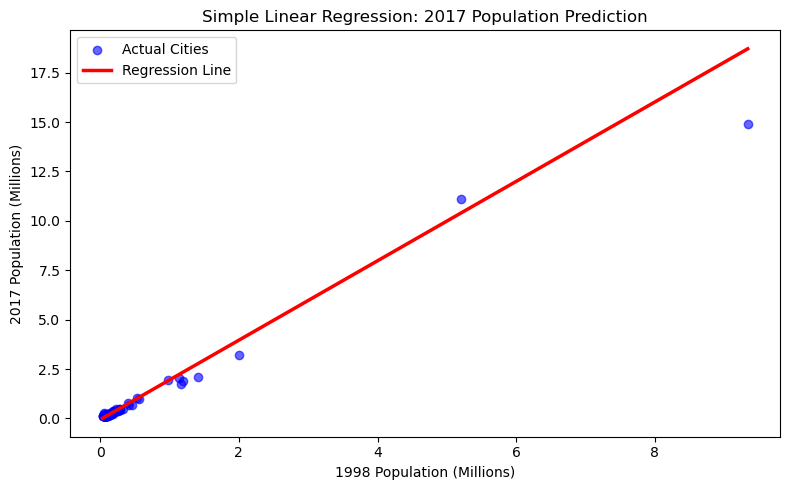

In [11]:
# Simple Linear Regression Visualization

X_sorted = X.sort_values("Population 1998 Census")
y_line = simple_model.predict(X_sorted)

plt.figure(figsize=(8, 5))
plt.scatter(X["Population 1998 Census"] / 1e6, y / 1e6, alpha=0.6, color="blue", label="Actual Cities")
plt.plot(X_sorted["Population 1998 Census"] / 1e6, y_line / 1e6, linewidth=2.5,color="red", label="Regression Line")

plt.xlabel("1998 Population (Millions)")
plt.ylabel("2017 Population (Millions)")
plt.title("Simple Linear Regression: 2017 Population Prediction")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Evaluate Simple Linear Regression
simple_r2 = r2_score(Y_test, simple_pred)
simple_mae = mean_absolute_error(Y_test, simple_pred)
simple_rmse = np.sqrt(np.mean((Y_test-simple_pred)**2))

print("R² =", simple_r2)
print("MAE =", simple_mae)
print("RMSE =", simple_rmse)

R² = 0.9294355951608667
MAE = 240947.80653554303
RMSE = 851078.1500684252


# Multi Regression


In [17]:
# Prepare Features
numeric_features = df[ ["Population 1998 Census", "Change"] ]
# Convert Province into numerical dummy variables
province = pd.get_dummies( df["Province"],dtype=int)

In [18]:
# Combine numerical features and province variables
X_multi = pd.concat( [numeric_features, province], axis=1)

In [20]:
print("Final Feature Set:")
display(X_multi.head())

Final Feature Set:


,Population 1998 Census,Change,Azad Kashmir,Balochistan,Islamabad,Khyber Pakhtunkhwa,Punjab,Sindh
0,9339023,0.5972,0,0,0,0,0,1
1,5209088,1.1359,0,0,0,0,1,0
2,2008861,0.5953,0,0,0,0,1,0
3,1409768,0.4884,0,0,0,0,1,0
4,1132509,0.7898,0,0,0,0,1,0


In [21]:
# Target variable
y_multi = df["Population 2017 Census"]

In [22]:
# Train-Test Split for Multiple Regression
X_train_m, X_test_m, Y_train_m, Y_test_m = train_test_split( X_multi, Y, test_size=0.2, random_state=42)

In [23]:
# Train the model
multi_model = LinearRegression()
multi_model.fit(X_train_m, Y_train_m)

LinearRegression()

In [24]:
#MAke PRedictions
multi_pred = multi_model.predict(X_test_m)

In [25]:
# Evaluate Multiple Linear Regression
multi_r2 = r2_score(Y_test_m, multi_pred)
multi_mae = mean_absolute_error(Y_test_m, multi_pred)
multi_rmse = np.sqrt(np.mean((Y_test_m - multi_pred) ** 2))

print("Multiple Regression Results")
print("R² =", multi_r2)
print("MAE =", multi_mae)
print("RMSE =", multi_rmse)

Multiple Regression Results
R² = 0.9300403279858465
MAE = 236373.70993337728
RMSE = 847423.4580958084


In [26]:
# Compare both models
if multi_r2 > simple_r2:
    print("Multiple Linear Regression performs better.")
else:
    print("Simple Linear Regression performs better.")

Multiple Linear Regression performs better.


### Why it Perform Better?

The multiple linear regression model is slightly better than the simple regression model. It has a higher R² score and lower MAE and RMSE values, so its predictions are more accurate.
This is because it uses more features to predict the 2017 population.

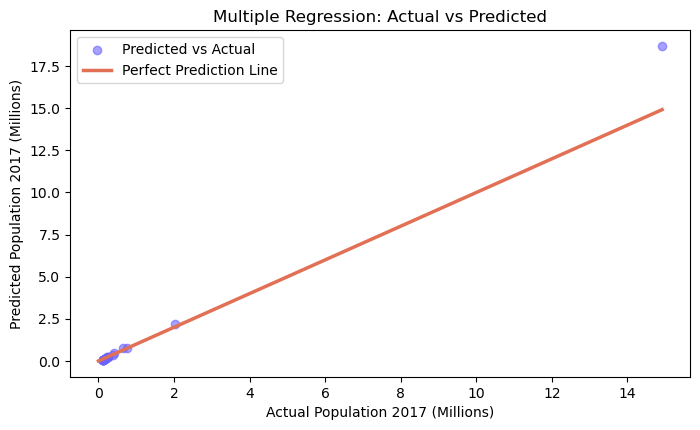

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4.5))
plt.scatter(Y_test_m/1e6, multi_pred/1e6, color="#6c63ff", alpha=0.6, label="Predicted vs Actual")
plt.plot([0, Y_test_m.max()/1e6], [0, Y_test_m.max()/1e6], color="#e17055", linewidth=2.5, label="Perfect Prediction Line")

plt.xlabel("Actual Population 2017 (Millions)")
plt.ylabel("Predicted Population 2017 (Millions)")
plt.title("Multiple Regression: Actual vs Predicted")
plt.legend()
plt.show()

In [44]:
# Feature Coefficients
print("Feature Coefficients")
coefficients = pd.DataFrame({"Feature": X_multi.columns,"Coefficient": multi_model.coef_})
print(coefficients)

Feature Coefficients
                  Feature    Coefficient
0  Population 1998 Census       2.013490
1                  Change  127931.206417
2            Azad Kashmir   41740.024212
3             Balochistan  -24958.314583
4               Islamabad  -11746.397818
5      Khyber Pakhtunkhwa   27482.949437
6                  Punjab   -8622.112339
7                   Sindh  -23896.148909


## Question
Which feature seems to have the biggest effect on predicted population? Does any coefficient surprise you?
## Answer:
The "Change" feature seems to have the biggest effect because it has the highest coefficient. This tells us that the city's growth rate is important for predicting its population.Some province coefficients are negative, which means those province variables reduce the predicted population in the model while the other features remain the same.

In [28]:
# Predict Population of Peshawar
city = df[df["City"] == "Peshawar"]
city

,Rank,City,Population 2017 Census,Population 1998 Census,Change,Province
5,6,Peshawar,1970042,982816,1.0045,Khyber Pakhtunkhwa


In [29]:
# Build the same feature set manually

city_numeric = city[["Population 1998 Census", "Change"]]
city_province = pd.get_dummies(city["Province"], dtype=int)
city_features = pd.concat([city_numeric, city_province], axis=1)

# Match the columns with the training data
city_features = city_features.reindex(columns=X_multi.columns, fill_value=0)
city_features

,Population 1998 Census,Change,Azad Kashmir,Balochistan,Islamabad,Khyber Pakhtunkhwa,Punjab,Sindh
5,982816,1.0045,0,0,0,1,0,0


In [30]:
#Predict the 2017 Population
prediction = multi_model.predict(city_features)
print("Predicted Population =", prediction[0])

Predicted Population = 1974759.7520340201


In [31]:
# Compare with Actual Population
actual = city["Population 2017 Census"].values[0]
print("Actual Population =", actual)

difference = abs(actual - prediction[0])
print("Difference =", difference)

Actual Population = 1970042
Difference = 4717.7520340201445


The predicted population is very close to the actual population. The difference is only about 4,718 people, which shows that the multiple linear regression model predicted the city's population quite accurately.